In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent
src_dir = project_root / "src"
data_dir = project_root / "data"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print(f"Project root: {project_root}")
print(f"Source dir: {src_dir}")
print(f"Data dir: {data_dir}")

Project root: /home/Elfetni/ML_UQ_LCA_pipeline/ml_uq_hydrothermal_pipeline
Source dir: /home/Elfetni/ML_UQ_LCA_pipeline/ml_uq_hydrothermal_pipeline/src
Data dir: /home/Elfetni/ML_UQ_LCA_pipeline/ml_uq_hydrothermal_pipeline/data


In [2]:
DATA_FILE = data_dir / "HTT_normalized_data_catalysts.csv"
htt_data = pd.read_csv(DATA_FILE, encoding="ISO-8859-1")

print(f"Loaded {len(htt_data)} rows from {DATA_FILE.name}")
print(f"Columns: {htt_data.shape[1]}")

Loaded 3693 rows from HTT_normalized_data_catalysts.csv
Columns: 226


In [3]:
BASE_X_NUM = [
    "O", "H", "C", "Ash",
    "O/C", "H/C",
    "LRI", "Lignin",
    "T", "t", "IC",
    "HHV_feedstock",
    "pressure_effective_mpa",
    "catalyst_biomass_ratio",
]

CAND_X_SOLV_NUM = [
    "frac_acetic_acid",
    "frac_formic_acid",
    "frac_nitric_acid",
    "frac_phosphoric_acid",
    "frac_sulfuric_acid",
    "frac_sodium_hydroxide",
    "frac_ethanol",
    "acid_M",
    "base_M",
    "phenol_additive_wt_pct",
]

CAND_X_SOLV_FLAG = [
    "acetic_acid_flag",
    "formic_acid_flag",
    "nitric_acid_flag",
    "phosphoric_acid_flag",
    "sulfuric_acid_flag",
    "sodium_hydroxide_flag",
    "ethanol_flag",
    "phenol_additive_flag",
]

CAND_X_CAT = [
    "Cat_Pt", "Cat_Pd", "Cat_Ru", "Cat_Ni", "Cat_Co",
    "Cat_Fe", "Cat_Cu", "Cat_Zn", "Cat_Mn", "Cat_Ce",
    "Cat_Zr", "Cat_Mo", "Cat_W", "Cat_V", "Cat_Al",
    "Cat_Zeolite", "Cat_Carbon", "Cat_Silica", "Cat_Alumina",
    "cat_ratio_log10",
]

CAND_X_NUM = BASE_X_NUM + CAND_X_SOLV_NUM + CAND_X_SOLV_FLAG + CAND_X_CAT

COLS_Y = [
    "B_Y", "C_Y", "A_Y", "G_Y",
    "E_B", "C_B", "E_H", "C_H",
    "HHV_B", "HHV_H",
    "HB", "HH",
    "OB", "OH",
    "CB", "CH",
    "NB", "NH",
    "SB", "SH",
    "BY_CY", "BY_AY", "BY_GY", "HY_BY",
]

print(f"Feature configuration defined")
print(f"Base numeric features: {len(BASE_X_NUM)}")
print(f"Solvent numeric features: {len(CAND_X_SOLV_NUM)}")
print(f"Solvent flags: {len(CAND_X_SOLV_FLAG)}")
print(f"Catalyst features: {len(CAND_X_CAT)}")
print(f"Total targets: {len(COLS_Y)}")

Feature configuration defined
Base numeric features: 14
Solvent numeric features: 10
Solvent flags: 8
Catalyst features: 20
Total targets: 24


## Database Overview Visualization

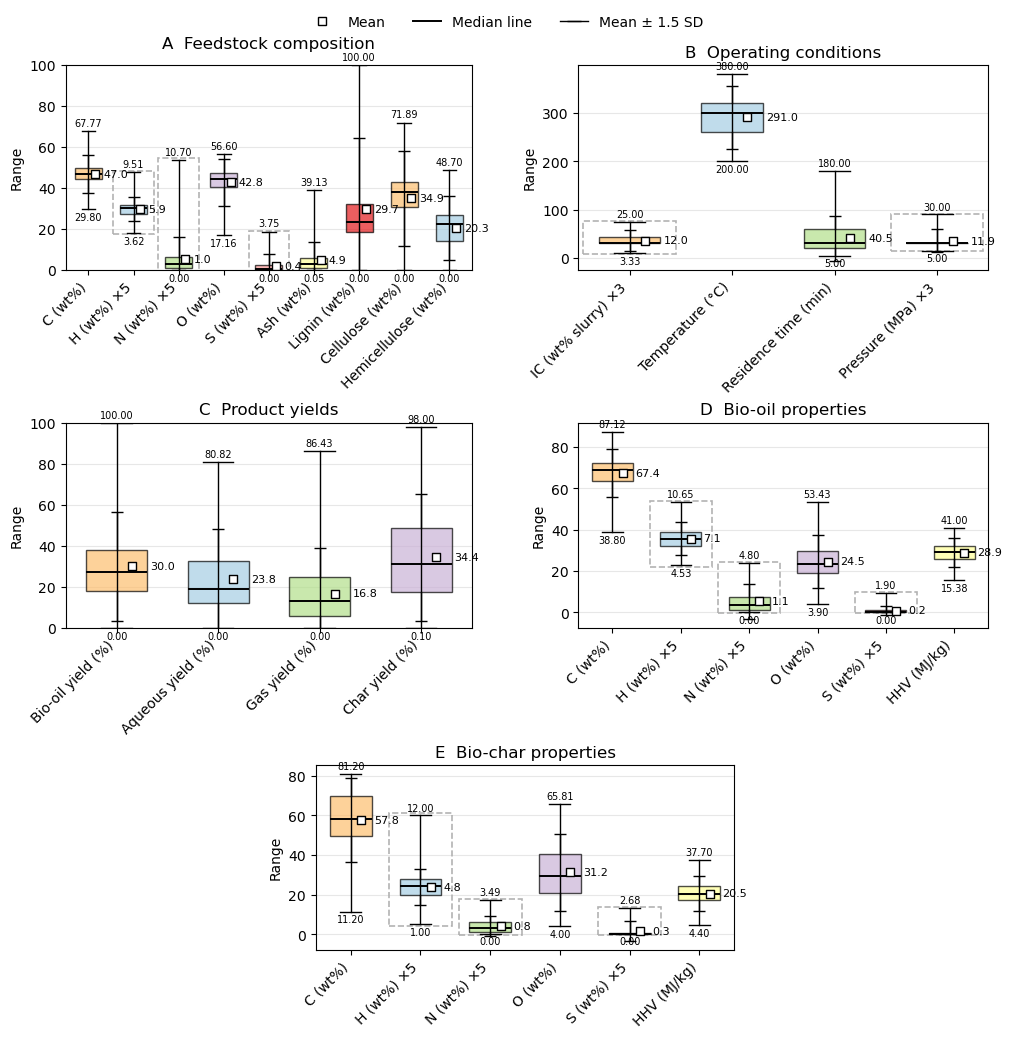

In [4]:
import importlib

if "plot_db_overview" in sys.modules:
    del sys.modules["plot_db_overview"]

import plot_db_overview
importlib.reload(plot_db_overview)

plot_db_overview.plot_db_overview(htt_data)

## Database Statistics

In [5]:
import importlib
import db_overview_stats
importlib.reload(db_overview_stats)

stats_dict, stats_dfs = plot_db_overview.db_overview_stats(htt_data, return_dfs=True)

stats_dfs["C_yields"]


A  Feedstock composition
(stats after clipping to 1.0–99.0 percentiles)
                     n    mean     std     min     max
variable                                              
C             3632.000  46.972   6.181  29.800  67.770
H             3589.000   5.945   0.801   3.620   9.510
N             2880.000   1.041   1.480   0.000  10.700
O             3640.000  42.794   7.660  17.160  56.600
S             2019.000   0.409   0.740   0.000   3.750
Ash           3614.000   4.909   5.911   0.050  39.130
Lignin        3552.000  29.691  23.082   0.000 100.000
cellulose     3503.000  34.940  15.379   0.000  71.890
hemicellulose 3521.000  20.328  10.389   0.000  48.700

B  Operating conditions
(stats after clipping to 5.0–95.0 percentiles)
                              n    mean     std     min     max
variable                                                       
IC                     3373.000  12.044   4.797   3.333  25.000
T                      3386.000 291.003  43.521 200.000 38

,n,mean,std,min,max
variable,,,,,
B_Y,2979.0,29.981129,17.614067,0.0,100.000000
A_Y,964.0,23.790528,16.260037,0.0,80.820000
G_Y,1135.0,16.751958,14.881551,0.0,86.428571
C_Y,2637.0,34.398028,20.759854,0.1,98.000000


## Sanity Checks - Encoding Coverage

In [7]:
assert "htt_data" in globals(), "htt_data must be loaded before running this block."

cols = set(htt_data.columns)

missing_solv_num = [c for c in CAND_X_SOLV_NUM if c not in cols]
extra_solv_num   = [
    c for c in htt_data.columns
    if (c.startswith("frac_") or c in ["acid_M", "base_M", "phenol_additive_wt_pct"])
    and c not in CAND_X_SOLV_NUM
]

print("\n Solvent numeric encoding:")
print("   Missing from CAND_X_SOLV_NUM:", missing_solv_num if missing_solv_num else "None")
print("   Extra numeric solvent cols not in CAND_X_SOLV_NUM:", extra_solv_num if extra_solv_num else "None")

missing_solv_flag = [c for c in CAND_X_SOLV_FLAG if c not in cols]
extra_solv_flag   = [
    c for c in htt_data.columns
    if c.endswith("_flag") and c not in CAND_X_SOLV_FLAG
]

print("\n Solvent flag encoding:")
print("   Missing from CAND_X_SOLV_FLAG:", missing_solv_flag if missing_solv_flag else "None")
print("   Extra *_flag cols not in CAND_X_SOLV_FLAG:", extra_solv_flag if extra_solv_flag else "None")

missing_cat_desc = [c for c in CAND_X_CAT if c not in cols]
extra_cat_desc   = [
    c for c in htt_data.columns
    if (c.startswith("Cat_") or c == "cat_ratio_log10") and c not in CAND_X_CAT
]

print("\n Catalyst descriptor encoding:")
print("   Missing from CAND_X_CAT:", missing_cat_desc if missing_cat_desc else "None")
print("   Extra catalyst descriptor cols not in CAND_X_CAT:", extra_cat_desc if extra_cat_desc else "None")

missing_base_num = [c for c in BASE_X_NUM if c not in cols]
extra_frac_core  = [
    c for c in htt_data.columns
    if c in ["O", "H", "C", "Ash", "O/C", "H/C", "LRI", "Lignin",
             "T", "t", "IC", "HHV_feedstock", "pressure_effective_mpa",
             "catalyst_biomass_ratio"]
    and c not in BASE_X_NUM
]

print("\n Core numeric encoding (BASE_X_NUM):")
print("   Missing from BASE_X_NUM:", missing_base_num if missing_base_num else "None")
print("   Extra core-like numeric cols not in BASE_X_NUM:", extra_frac_core if extra_frac_core else "None")

missing_targets = [c for c in COLS_Y if c not in cols]
print("\n Targets (COLS_Y):")
print("   Missing target columns:", missing_targets if missing_targets else "None")


 Solvent numeric encoding:
   Missing from CAND_X_SOLV_NUM: ['frac_acetic_acid', 'frac_formic_acid', 'frac_nitric_acid', 'frac_phosphoric_acid', 'frac_sulfuric_acid', 'frac_sodium_hydroxide']
   Extra numeric solvent cols not in CAND_X_SOLV_NUM: ['frac_water', 'frac_methanol', 'frac_isopropanol', 'frac_acetone', 'frac_glycerol']

 Solvent flag encoding:
   Missing from CAND_X_SOLV_FLAG: ['acetic_acid_flag', 'formic_acid_flag', 'nitric_acid_flag', 'phosphoric_acid_flag', 'sulfuric_acid_flag', 'sodium_hydroxide_flag', 'ethanol_flag', 'phenol_additive_flag']
   Extra *_flag cols not in CAND_X_SOLV_FLAG: ['LCH_flag', 'QA_flag', 'acid_flag', 'base_flag', 'H_donor_flag']

 Catalyst descriptor encoding:
   Missing from CAND_X_CAT: ['Cat_Pt', 'Cat_Pd', 'Cat_Ru', 'Cat_Ni', 'Cat_Co', 'Cat_Fe', 'Cat_Cu', 'Cat_Zn', 'Cat_Mn', 'Cat_Ce', 'Cat_Zr', 'Cat_Mo', 'Cat_W', 'Cat_V', 'Cat_Al', 'Cat_Zeolite', 'Cat_Carbon', 'Cat_Silica', 'Cat_Alumina', 'cat_ratio_log10']
   Extra catalyst descriptor cols not i